In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import GridSearchCV

# 📦📥Data Collection (Load the Dataset)

In [ ]:
dataset = pd.read_csv("Gemstone_Dataset.csv")
dataset.head(5)

,GemName,carat,cut,clarity,depth,table,x,y,z,Lab_L,Lab_a,Lab_b,XYZ_X,XYZ_Y,XYZ_Z,Wavelength,Reflectance,Color
0,Topaz,4.25,Ideal,SI2,55.72,55.74,8.63,NaN,5.22,69.31,2.36,4.99,0.153,0.554,0.538,650.0,0.37,Red
1,Topaz,3.88,Good,IF,62.14,65.66,8.58,9.17,5.52,78.91,3.66,-1.66,0.220,0.511,0.496,600.0,0.41,Green
2,Diamond,2.02,NaN,VVS2,58.99,54.47,3.84,5.93,2.95,66.57,1.52,1.80,0.387,0.374,0.204,400.0,0.56,Red
3,Sapphire,2.50,Ideal,SI1,59.82,54.95,8.91,4.19,5.10,75.83,1.12,2.51,NaN,0.400,0.561,500.0,0.37,LightYellow
4,Amethyst,1.09,Premium,IF,61.04,56.49,3.54,3.13,4.99,64.55,1.08,-0.06,0.297,0.310,0.214,650.0,0.39,FaintYellow


# 🧬Data Preprocessing

In [ ]:
print("Dataset Shape:", dataset.shape)
print("Column Names:\n", dataset.columns.tolist())

Dataset Shape: (10000, 18)
Column Names:
 ['GemName', 'carat', 'cut', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'Lab_L', 'Lab_a', 'Lab_b', 'XYZ_X', 'XYZ_Y', 'XYZ_Z', 'Wavelength', 'Reflectance', 'Color']


In [ ]:
print("Dataset Info:")
dataset.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GemName      9803 non-null   object 
 1   carat        9805 non-null   float64
 2   cut          9802 non-null   object 
 3   clarity      9802 non-null   object 
 4   depth        9802 non-null   float64
 5   table        9802 non-null   float64
 6   x            9803 non-null   float64
 7   y            9803 non-null   float64
 8   z            9801 non-null   float64
 9   Lab_L        9803 non-null   float64
 10  Lab_a        9800 non-null   float64
 11  Lab_b        9804 non-null   float64
 12  XYZ_X        9801 non-null   float64
 13  XYZ_Y        9801 non-null   float64
 14  XYZ_Z        9802 non-null   float64
 15  Wavelength   9804 non-null   float64
 16  Reflectance  9803 non-null   float64
 17  Color        9813 non-null   object 
dtypes: float64(14), object(4)
memory 

In [ ]:
print("Statistical Summary:")
dataset.describe()

Statistical Summary:


,carat,depth,table,x,y,z,Lab_L,Lab_a,Lab_b,XYZ_X,XYZ_Y,XYZ_Z,Wavelength,Reflectance
count,9805.000000,9802.000000,9802.000000,9803.000000,9803.000000,9801.000000,9803.000000,9800.000000,9804.000000,9801.000000,9801.000000,9802.000000,9804.000000,9803.000000
mean,2.641141,60.033553,60.071076,6.524334,6.491591,4.246327,70.028095,3.001661,-0.000413,0.348323,0.348478,0.349620,550.066299,0.502050
std,1.382442,2.893372,5.764626,2.026721,2.038210,1.286027,5.770262,1.153765,2.885680,0.144671,0.144146,0.144415,99.430930,0.115865
min,0.200000,52.360000,50.000000,2.880000,3.000000,2.000000,60.010000,1.000000,-5.000000,0.025400,0.100000,0.100000,400.000000,0.300000
25%,1.460000,57.530000,55.120000,4.780000,4.730000,3.140000,65.010000,1.990000,-2.520000,0.223000,0.224000,0.225000,450.000000,0.400000
50%,2.660000,60.040000,60.085000,6.500000,6.460000,4.250000,70.080000,3.010000,0.030000,0.346000,0.347000,0.348000,550.000000,0.500000
75%,3.820000,62.570000,65.110000,8.310000,8.280000,5.340000,74.950000,3.990000,2.480000,0.473000,0.471000,0.477000,650.000000,0.600000
max,5.000000,65.000000,70.000000,10.000000,10.000000,6.500000,80.000000,5.000000,5.000000,0.600000,0.600000,0.600000,700.000000,0.700000


In [ ]:
print("Missing Values per Column:")
print(dataset.isnull().sum())

Missing Values per Column:
GemName        197
carat          195
cut            198
clarity        198
depth          198
table          198
x              197
y              197
z              199
Lab_L          197
Lab_a          200
Lab_b          196
XYZ_X          199
XYZ_Y          199
XYZ_Z          198
Wavelength     196
Reflectance    197
Color          187
dtype: int64


In [ ]:
print("Unique Color Classes:")
print(dataset['Color'].unique())

Unique Color Classes:
['Red' 'Green' 'LightYellow' 'FaintYellow' 'Blue' 'White' 'Violet' nan]


In [ ]:
print("Color Distribution:")
print(dataset['Color'].value_counts())

Color Distribution:
Color
FaintYellow    1433
White          1427
Blue           1424
LightYellow    1410
Red            1397
Violet         1367
Green          1355
Name: count, dtype: int64


In [ ]:
dataset.drop(columns=['GemName'], inplace=True)

In [ ]:
print(" Missing Values:\n", dataset.isnull().sum())

 Missing Values:
 carat          195
cut            198
clarity        198
depth          198
table          198
x              197
y              197
z              199
Lab_L          197
Lab_a          200
Lab_b          196
XYZ_X          199
XYZ_Y          199
XYZ_Z          198
Wavelength     196
Reflectance    197
Color          187
dtype: int64


In [ ]:
# Fill missing numerical values with column mean
num_cols = dataset.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    dataset[col] = dataset[col].fillna(dataset[col].mean())

# Fill missing categorical columns with mode
cat_cols = dataset.select_dtypes(include='object').columns

for col in cat_cols:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

In [ ]:
before = dataset.shape[0]
dataset.drop_duplicates(inplace = True)
after = dataset.shape[0]

print(f"Removed {before - after} duplicate rows.")

Removed 0 duplicate rows.


# 🔍Label encoding (Exploratory Data Analysis (EDA))

In [ ]:
# Encode categorical columns (except 'Color' for now)

label_encoders = {}
for col in dataset.select_dtypes(include='object').columns:
    if col != 'Color':  # Don't encode target column here
        le = LabelEncoder()
        dataset[col] = le.fit_transform(dataset[col])
        label_encoders[col] = le

# Display processed data
dataset.head()

,carat,cut,clarity,depth,table,x,y,z,Lab_L,Lab_a,Lab_b,XYZ_X,XYZ_Y,XYZ_Z,Wavelength,Reflectance,Color
0,4.25,2,2,55.72,55.74,8.63,6.491591,5.22,69.31,2.36,4.99,0.153000,0.554,0.538,650.0,0.37,Red
1,3.88,1,0,62.14,65.66,8.58,9.170000,5.52,78.91,3.66,-1.66,0.220000,0.511,0.496,600.0,0.41,Green
2,2.02,4,6,58.99,54.47,3.84,5.930000,2.95,66.57,1.52,1.80,0.387000,0.374,0.204,400.0,0.56,Red
3,2.50,2,1,59.82,54.95,8.91,4.190000,5.10,75.83,1.12,2.51,0.348323,0.400,0.561,500.0,0.37,LightYellow
4,1.09,3,0,61.04,56.49,3.54,3.130000,4.99,64.55,1.08,-0.06,0.297000,0.310,0.214,650.0,0.39,FaintYellow


In [ ]:
print("\n Final Shape After Cleaning:", dataset.shape)
print("\n Any Missing Values Left?\n", dataset.isnull().sum().sum())


 Final Shape After Cleaning: (10000, 17)

 Any Missing Values Left?
 0


In [ ]:
dataset.to_csv("Gems_dataset.csv", index=False)

In [ ]:
dataset.describe()

,carat,cut,clarity,depth,table,x,y,z,Lab_L,Lab_a,Lab_b,XYZ_X,XYZ_Y,XYZ_Z,Wavelength,Reflectance
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2.641141,2.061200,3.01110,60.033553,60.071076,6.524334,6.491591,4.246327,70.028095,3.001661,-0.000413,0.348323,0.348478,0.349620,550.066299,0.502050
std,1.368895,1.428586,1.96829,2.864582,5.707265,2.006656,2.018032,1.273166,5.713137,1.142168,2.857257,0.143224,0.142705,0.142978,98.451587,0.114718
min,0.200000,0.000000,0.00000,52.360000,50.000000,2.880000,3.000000,2.000000,60.010000,1.000000,-5.000000,0.025400,0.100000,0.100000,400.000000,0.300000
25%,1.490000,1.000000,1.00000,57.600000,55.210000,4.810000,4.770000,3.160000,65.120000,2.010000,-2.460000,0.225000,0.227000,0.227000,450.000000,0.400000
50%,2.641141,2.000000,3.00000,60.033553,60.071076,6.524334,6.491591,4.246327,70.028095,3.001661,-0.000413,0.348323,0.348478,0.349620,550.000000,0.502050
75%,3.800000,3.000000,5.00000,62.502500,65.020000,8.280000,8.240000,5.320000,74.860000,3.970000,2.430000,0.470250,0.468000,0.475000,650.000000,0.600000
max,5.000000,4.000000,6.00000,65.000000,70.000000,10.000000,10.000000,6.500000,80.000000,5.000000,5.000000,0.600000,0.600000,0.600000,700.000000,0.700000


# 📈📊Data Visualization

C:\Users\01\AppData\Local\Temp\ipykernel_12816\2682292561.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x='Color', order=color_order, palette=bar_colors)


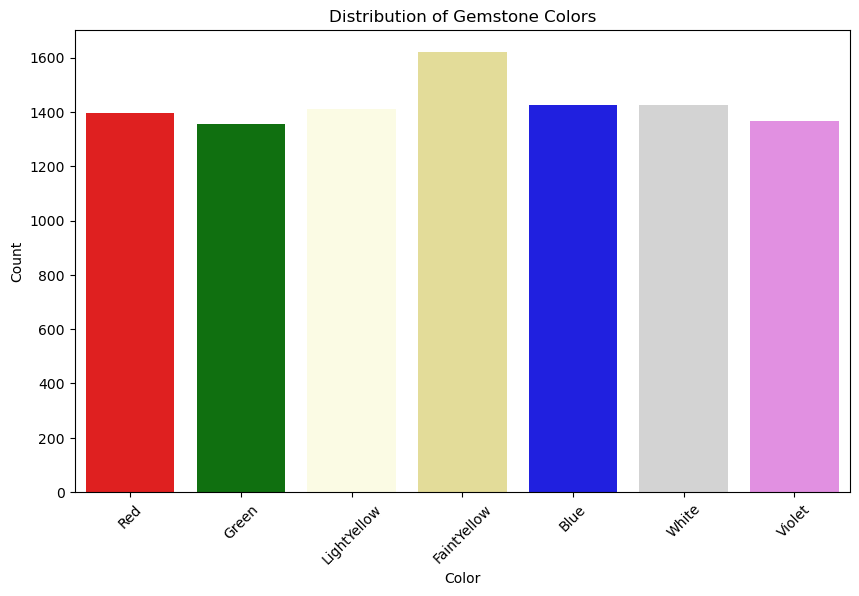

In [ ]:
#Distribution of Target Variable (Color)

color_order = ['Red', 'Green', 'LightYellow', 'FaintYellow', 'Blue', 'White', 'Violet']
bar_colors = ['red', 'green', 'lightyellow', 'khaki', 'blue', 'lightgrey', 'violet']

plt.figure(figsize=(10, 6))
sns.countplot(data=dataset, x='Color', order=color_order, palette=bar_colors)
plt.title("Distribution of Gemstone Colors")
plt.xlabel("Color")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### **Heatmap**

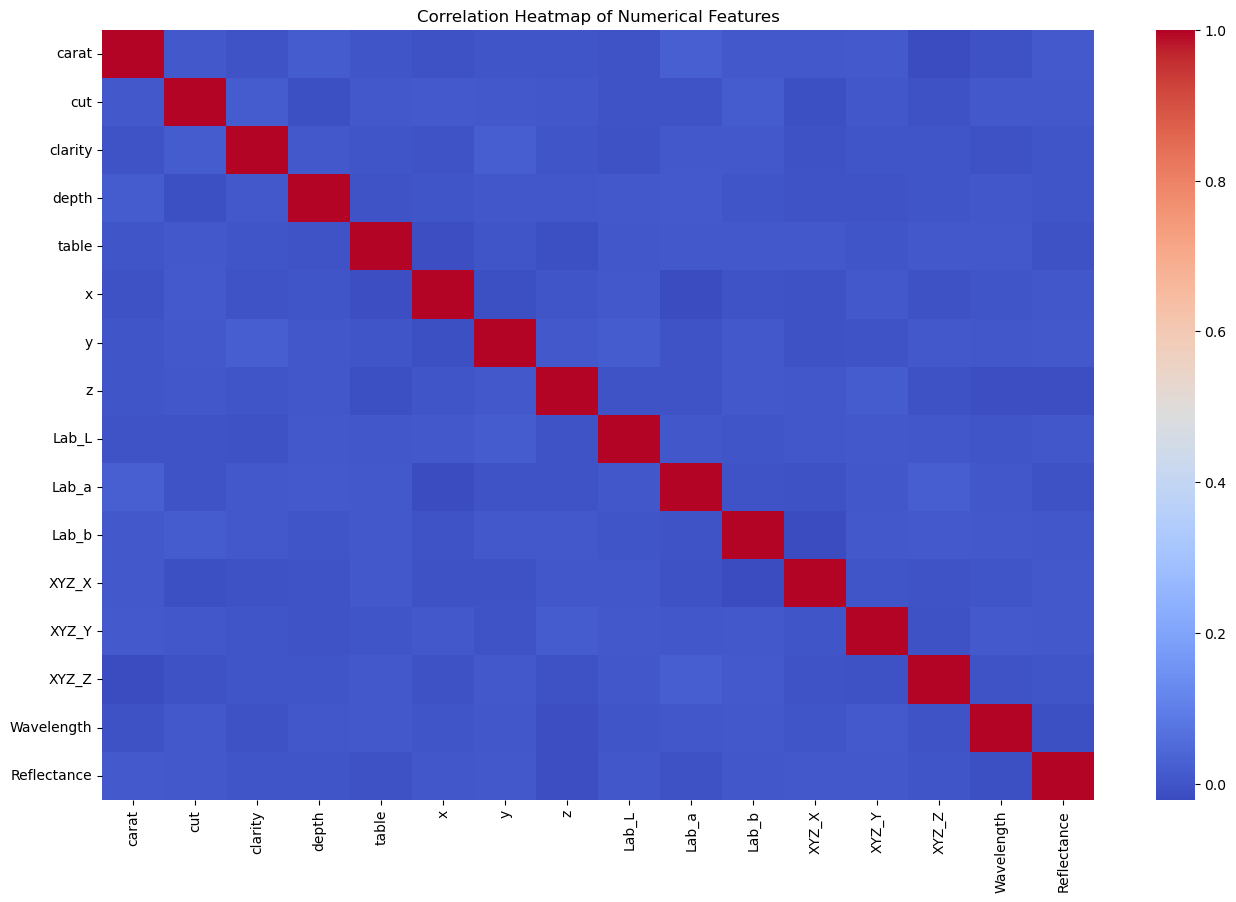

In [ ]:
#Correlation Heatmap (for numerical features)
numeric_data = dataset.select_dtypes(include=['number'])

plt.figure(figsize=(16, 10))
sns.heatmap(numeric_data.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

#### **Line chart**

Numerical columns: ['carat', 'cut', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'Lab_L', 'Lab_a', 'Lab_b', 'XYZ_X', 'XYZ_Y', 'XYZ_Z', 'Wavelength', 'Reflectance']


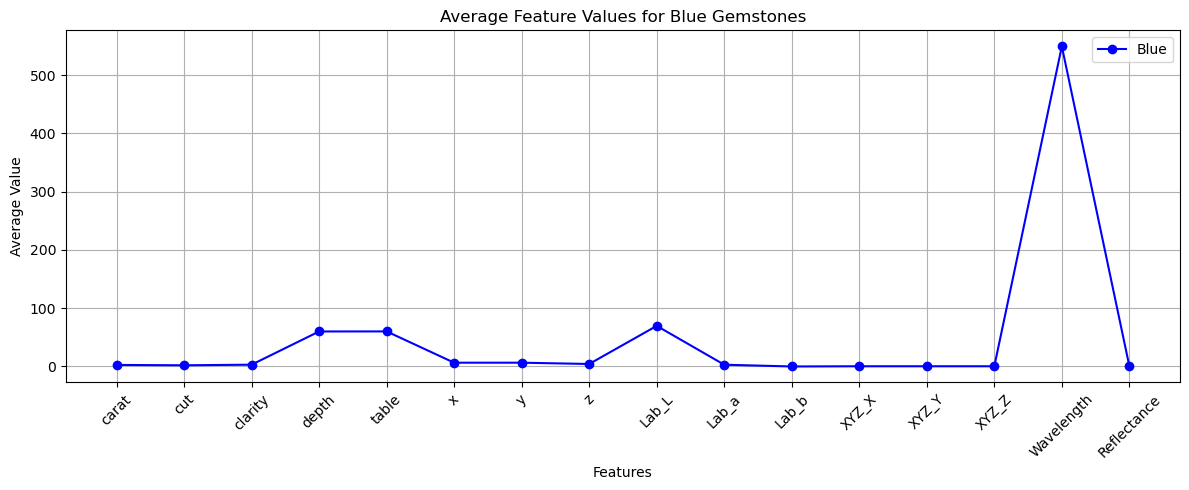

In [ ]:
# Display column names to choose from
print("Numerical columns:", dataset.select_dtypes(include='number').columns.tolist())

# Choose specific color (e.g. 'Red')
selected_color = 'Blue'

# Filter that color and compute mean for features
color_dataset = dataset[dataset['Color'] == selected_color].mean(numeric_only=True)

# Plot line chart for selected color
plt.figure(figsize=(12, 5))
plt.plot(color_dataset.index, color_dataset.values, marker='o', color='blue', label=selected_color)

plt.title(f"Average Feature Values for {selected_color} Gemstones")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

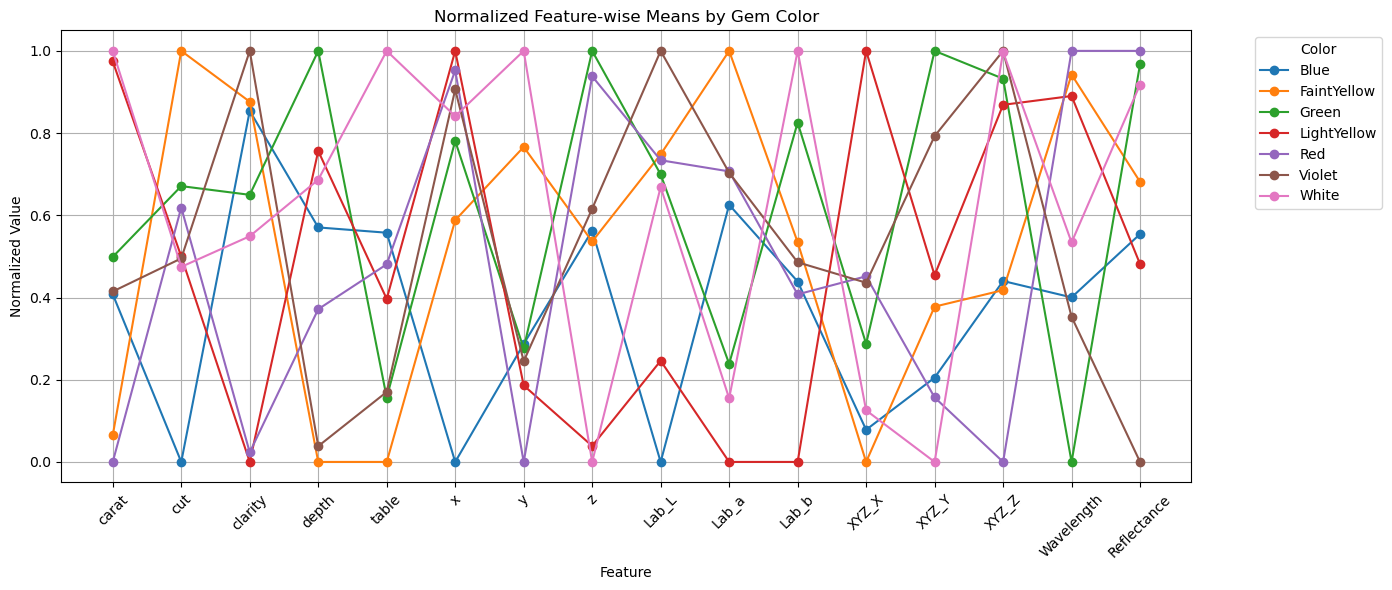

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Group by Color and calculate mean
color_means = dataset.groupby("Color").mean(numeric_only=True)

# Normalize feature values (0 to 1 scale)
scaler = MinMaxScaler()
normalized_means = pd.DataFrame(
    scaler.fit_transform(color_means),
    columns=color_means.columns,
    index=color_means.index
)

# Transpose for plotting
normalized_means_T = normalized_means.T

# Plotting
plt.figure(figsize=(14, 6))
for color in normalized_means_T.columns:
    plt.plot(normalized_means_T.index, normalized_means_T[color], marker='o', label=color)

plt.title("Normalized Feature-wise Means by Gem Color")
plt.xlabel("Feature")
plt.ylabel("Normalized Value")
plt.xticks(rotation=45)
plt.legend(title="Color", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### **Pairplot**

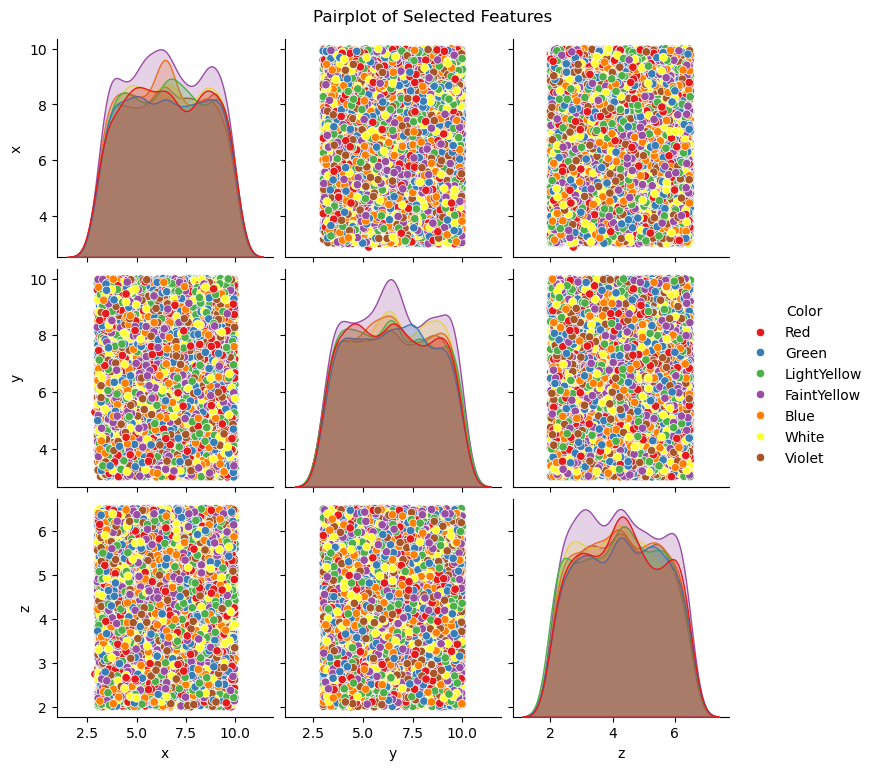

In [ ]:
#Pairplot of Select Features Colored by Color
#(Use only top 4-5 features to avoid overload)

# Select a few numerical columns + 'Color'
selected_cols = ['x', 'y', 'z', 'Color']
sns.pairplot(dataset[selected_cols], hue='Color', palette='Set1')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

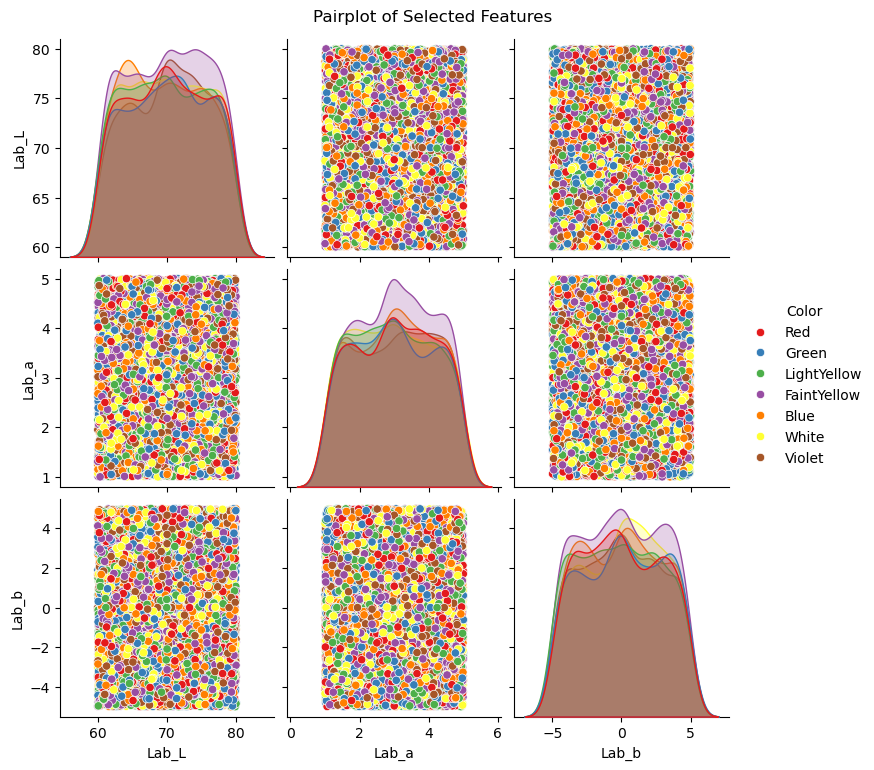

In [ ]:
selected_cols = ['Lab_L', 'Lab_a', 'Lab_b', 'Color']
sns.pairplot(dataset[selected_cols], hue='Color', palette='Set1')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

#### **Boxplot**

C:\Users\01\AppData\Local\Temp\ipykernel_12816\2814491578.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x='Color', y='carat', order=color_order, palette=bar_colors)


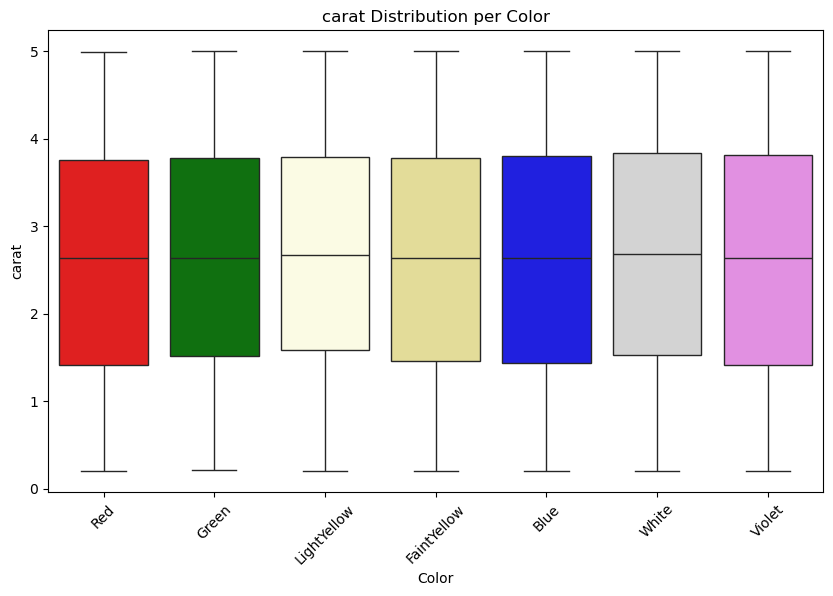

In [ ]:
#Boxplot for Feature vs Color

plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset, x='Color', y='carat', order=color_order, palette=bar_colors)
plt.title("carat Distribution per Color")
plt.xticks(rotation=45)
plt.show()

C:\Users\01\AppData\Local\Temp\ipykernel_12816\1553353527.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x='Color', y='Reflectance', order=color_order, palette=bar_colors)


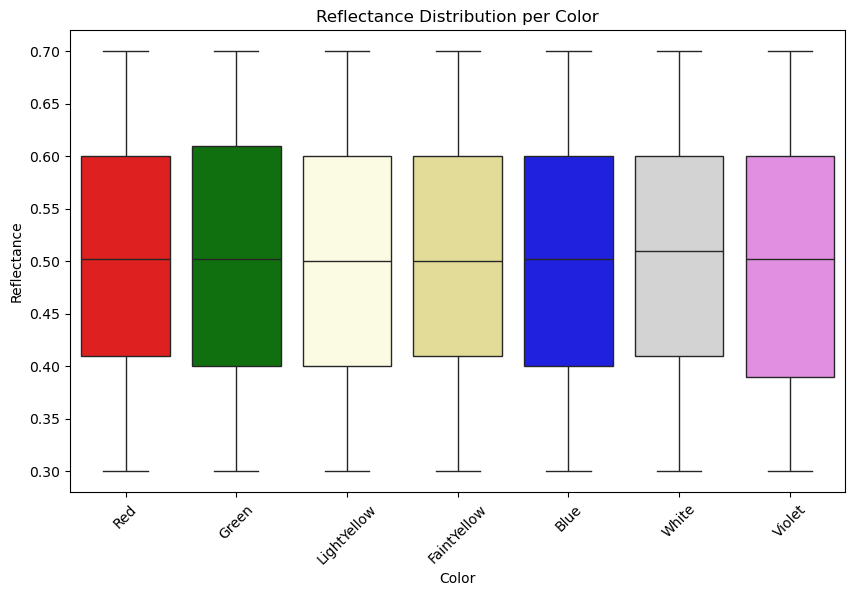

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset, x='Color', y='Reflectance', order=color_order, palette=bar_colors)
plt.title("Reflectance Distribution per Color")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Skewness of all numeric features
numeric_skew = dataset.select_dtypes(include='number').skew()
print("Skewness of all numeric features:\n")
print(numeric_skew.sort_values(ascending=False))

Skewness of all numeric features:

XYZ_X          0.018745
XYZ_Y          0.014797
z              0.010649
y              0.009761
XYZ_Z          0.006425
x              0.003809
Wavelength    -0.002243
Lab_b         -0.008275
clarity       -0.009248
Lab_a         -0.009279
Lab_L         -0.010672
depth         -0.012714
table         -0.022151
Reflectance   -0.027470
carat         -0.037343
cut           -0.050604
dtype: float64


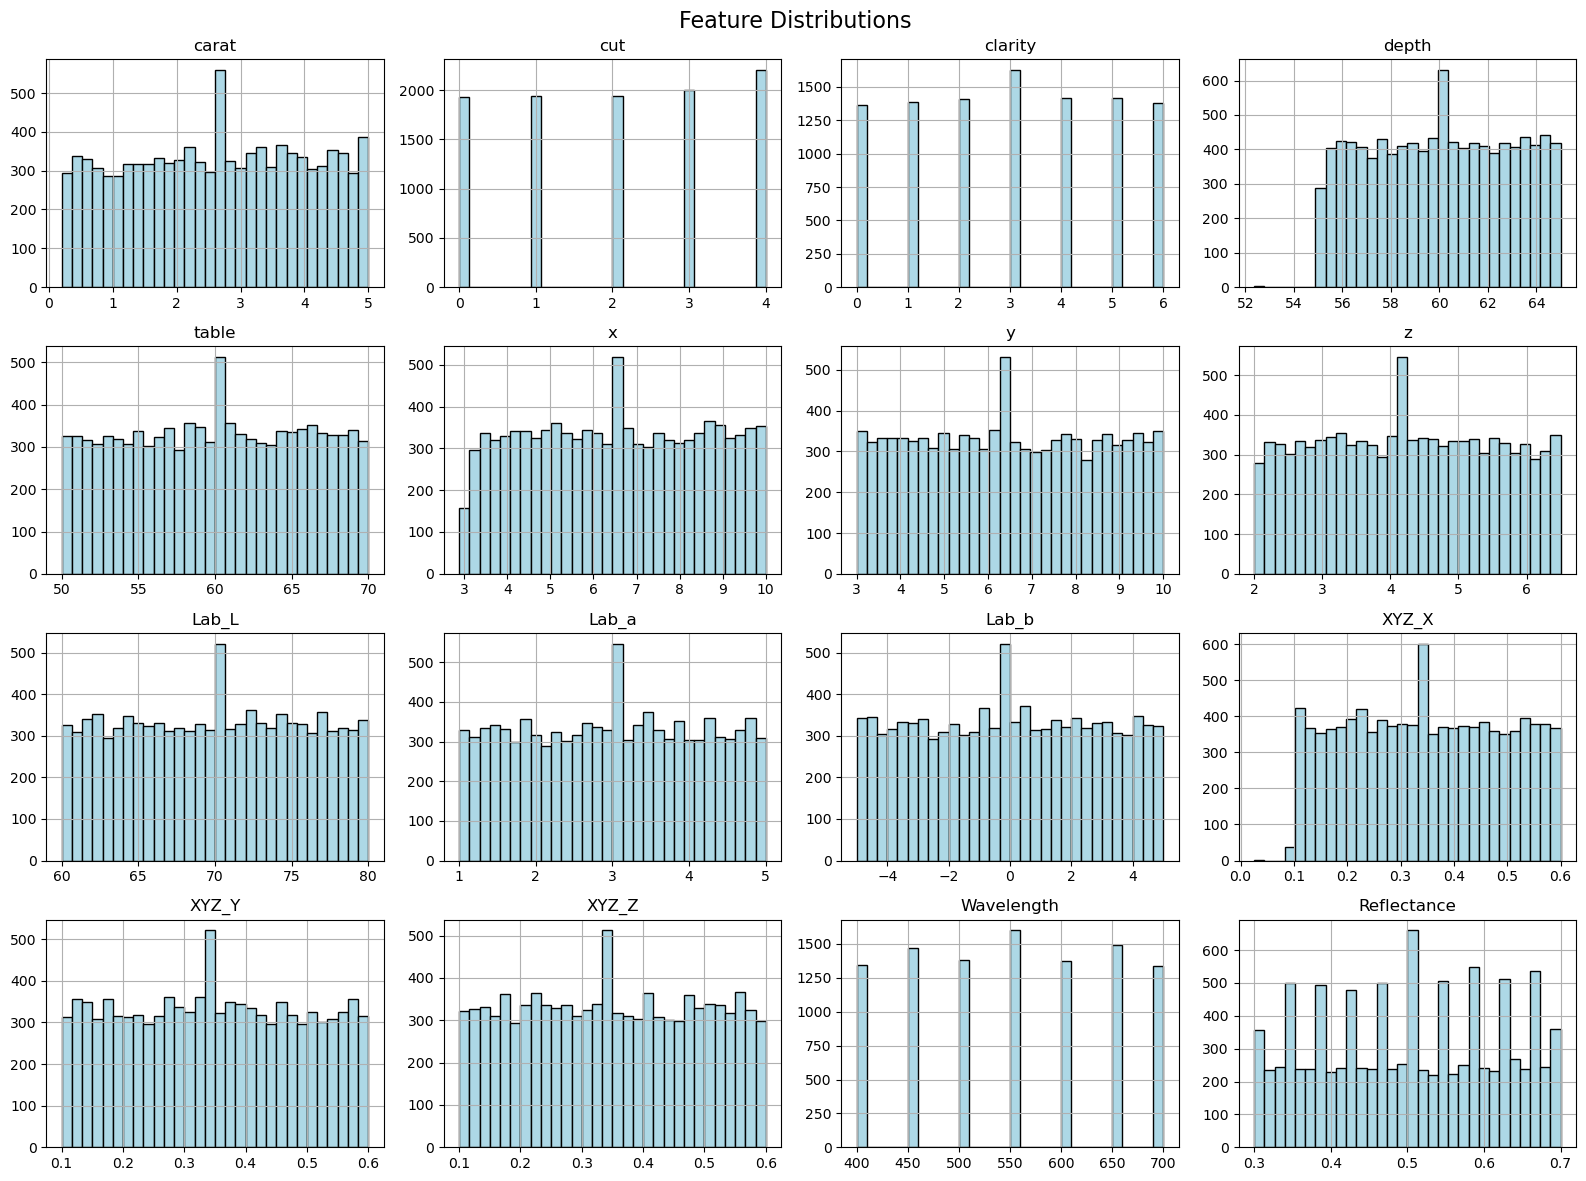

In [ ]:
# Histograms
dataset.hist(figsize=(16, 12), bins=30, color='lightblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

# ⚙️Feature Selection / Engineering
**Goal: Select the most relevant features that help predict gemstone Color.**

In [ ]:
# Separate features and target
X = dataset.drop('Color', axis=1)
y = dataset['Color']

# Encode target labels
from sklearn.preprocessing import LabelEncoder
color_encoder = LabelEncoder()
y_encoded = color_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Fit model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns

# Create DataFrame of feature importance
feature_imp_dataset = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_dataset = feature_imp_dataset.sort_values(by='Importance', ascending=False)

# Display
feature_imp_dataset

,Feature,Importance
10,Lab_b,0.070449
12,XYZ_Y,0.070438
3,depth,0.069824
8,Lab_L,0.069809
6,y,0.069763
5,x,0.069640
0,carat,0.069505
13,XYZ_Z,0.069231
4,table,0.069121
7,z,0.068563


C:\Users\01\AppData\Local\Temp\ipykernel_12816\3216739006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_dataset.head(16), x='Importance', y='Feature', palette='viridis')


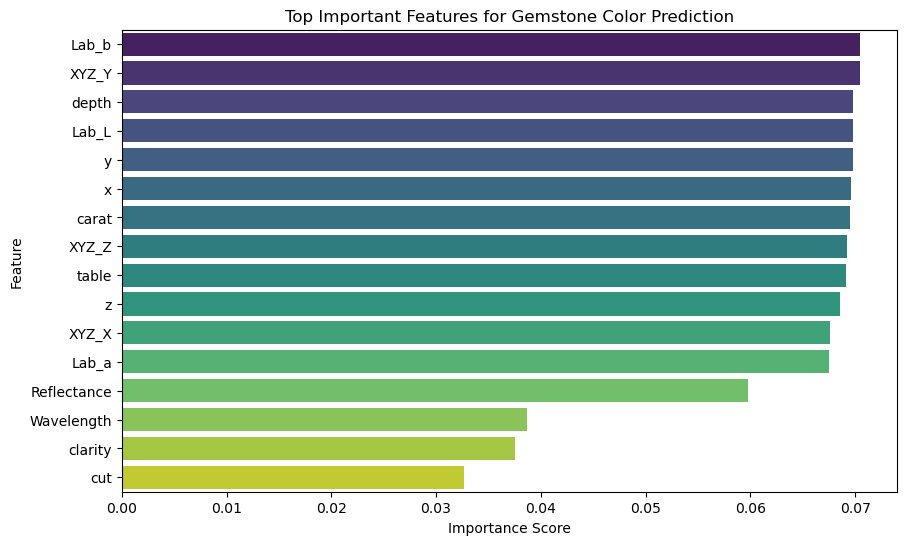

In [ ]:
#Plot Feature Importances

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_dataset.head(16), x='Importance', y='Feature', palette='viridis')
plt.title("Top Important Features for Gemstone Color Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [ ]:
'''#(Optional) Drop Low-Importance Features
#You can drop features with very low importance (e.g., < 0.01), depending on the goal and model performance.

# Keep only important features (optional step)
important_features = feature_imp_dataset[feature_imp_dataset['Importance'] > 0.01]['Feature']
X = X[important_features]'''

"#(Optional) Drop Low-Importance Features\n#You can drop features with very low importance (e.g., < 0.01), depending on the goal and model performance.\n\n# Keep only important features (optional step)\nimportant_features = feature_imp_dataset[feature_imp_dataset['Importance'] > 0.01]['Feature']\nX = X[important_features]"

# 🤖Model Selection & Training

In [ ]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [ ]:
#Train & Evaluate Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\nModel: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=color_encoder.classes_))


C:\Users\01\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression
Accuracy: 0.1450
Classification Report:
              precision    recall  f1-score   support

        Blue       0.15      0.11      0.12       297
 FaintYellow       0.14      0.53      0.23       318
       Green       0.13      0.02      0.03       280
 LightYellow       0.14      0.15      0.15       279
         Red       0.20      0.01      0.02       310
      Violet       0.00      0.00      0.00       257
       White       0.15      0.15      0.15       259

    accuracy                           0.14      2000
   macro avg       0.13      0.14      0.10      2000
weighted avg       0.13      0.14      0.10      2000


Model: Random Forest
Accuracy: 0.1525
Classification Report:
              precision    recall  f1-score   support

        Blue       0.17      0.17      0.17       297
 FaintYellow       0.15      0.25      0.19       318
       Green       0.10      0.07      0.08       280
 LightYellow       0.15      0.15      0.15       279
  

C:\Users\01\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\01\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\01\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


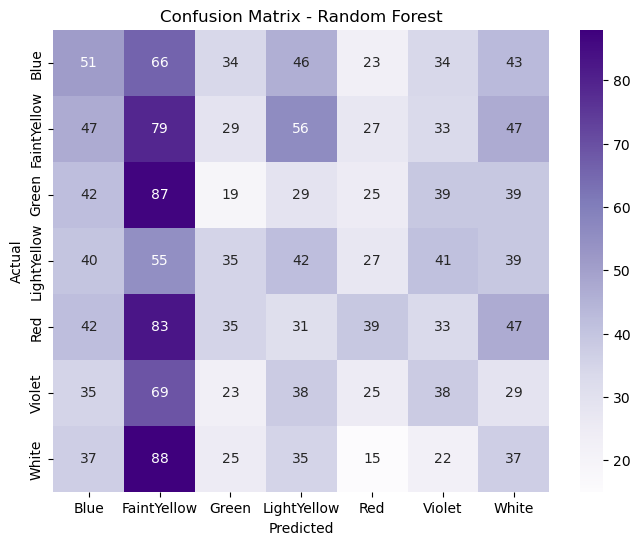

In [ ]:
#Confusion Matrix for Best Model

best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Purples', xticklabels=color_encoder.classes_, yticklabels=color_encoder.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🎯Model Evaluation with Cross-Validation and Tuning

In [ ]:
# Use 5-fold cross-validation
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf_model, X, y_encoded, cv=5)

# Display results
print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy: {:.4f}".format(np.mean(cv_scores)))
print("Standard Deviation: {:.4f}".format(np.std(cv_scores)))


Cross-Validation Scores: [0.1415 0.136  0.151  0.15   0.1455]
Mean Accuracy: 0.1448
Standard Deviation: 0.0056


In [ ]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Create GridSearch object
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='accuracy',
                           n_jobs=-1)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best parameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy: {:.4f}".format(grid_search.best_score_))

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}
Best Accuracy: 0.1531


In [ ]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

# Accuracy and report

print("Tuned Model Test Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Classification Report:\n", classification_report(y_test, y_pred_tuned, target_names=color_encoder.classes_))

Tuned Model Test Accuracy: 0.1515
Classification Report:
               precision    recall  f1-score   support

        Blue       0.16      0.08      0.11       297
 FaintYellow       0.15      0.54      0.24       318
       Green       0.09      0.02      0.03       280
 LightYellow       0.19      0.14      0.16       279
         Red       0.15      0.04      0.07       310
      Violet       0.14      0.05      0.08       257
       White       0.13      0.14      0.13       259

    accuracy                           0.15      2000
   macro avg       0.14      0.15      0.12      2000
weighted avg       0.14      0.15      0.12      2000



# 🔮Model Saving

In [ ]:
import joblib

# Save model and encoder
joblib.dump(best_rf, "gem_color_model.pkl")
joblib.dump(color_encoder, "color_label_encoder.pkl")


['color_label_encoder.pkl']

# 🚀Model Deployment
Use Streamlit to create a web app for prediction